In [1]:
%matplotlib inline

In [2]:
from time import time

from os import path

import pandas as pd

import numpy as np

from ipywidgets import interactive

import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.signal import butter, filtfilt

#!pip install obspy

In [3]:
#segysak (https://trhallam.github.io/segysak/latest/)
#!pip install segysak
import segysak


from segysak.segy import get_segy_texthead, segy_header_scan, segy_header_scrape

#xarray (https://docs.xarray.dev/en/stable/)
#!pip install xarray
import xarray as xr

#Cartopy (https://scitools.org.uk/cartopy/docs/latest/)
#!pip install cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes

#pyproj
#!pip install pyproj
import pyproj

In [4]:
segy_file = "/home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_teste_SEGY/segy/247_Santos_part1c.sgy"
print("Arquivo sísmica 2D:", segy_file,"\nExiste:",path.exists(segy_file))

Aquivo sísmica 2D: /home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_teste_SEGY/segy/247_Santos_part1c.sgy 
Existe: True


In [9]:
from segysak.segy import segy_header_scrape

scrape = segy_header_scrape(segy_file, partial_scan=None)


Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/52.8k [00:00<?, ? traces/s]

In [10]:
scrape.columns

Index(['TRACE_SEQUENCE_LINE', 'TRACE_SEQUENCE_FILE', 'FieldRecord',
       'TraceNumber', 'EnergySourcePoint', 'CDP', 'CDP_TRACE',
       'TraceIdentificationCode', 'NSummedTraces', 'NStackedTraces', 'DataUse',
       'offset', 'ReceiverGroupElevation', 'SourceSurfaceElevation',
       'SourceDepth', 'ReceiverDatumElevation', 'SourceDatumElevation',
       'SourceWaterDepth', 'GroupWaterDepth', 'ElevationScalar',
       'SourceGroupScalar', 'SourceX', 'SourceY', 'GroupX', 'GroupY',
       'CoordinateUnits', 'WeatheringVelocity', 'SubWeatheringVelocity',
       'SourceUpholeTime', 'GroupUpholeTime', 'SourceStaticCorrection',
       'GroupStaticCorrection', 'TotalStaticApplied', 'LagTimeA', 'LagTimeB',
       'DelayRecordingTime', 'MuteTimeStart', 'MuteTimeEND',
       'TRACE_SAMPLE_COUNT', 'TRACE_SAMPLE_INTERVAL', 'GainType',
       'InstrumentGainConstant', 'InstrumentInitialGain', 'Correlated',
       'SweepFrequencyStart', 'SweepFrequencyEnd', 'SweepLength', 'SweepType',
       'Swee

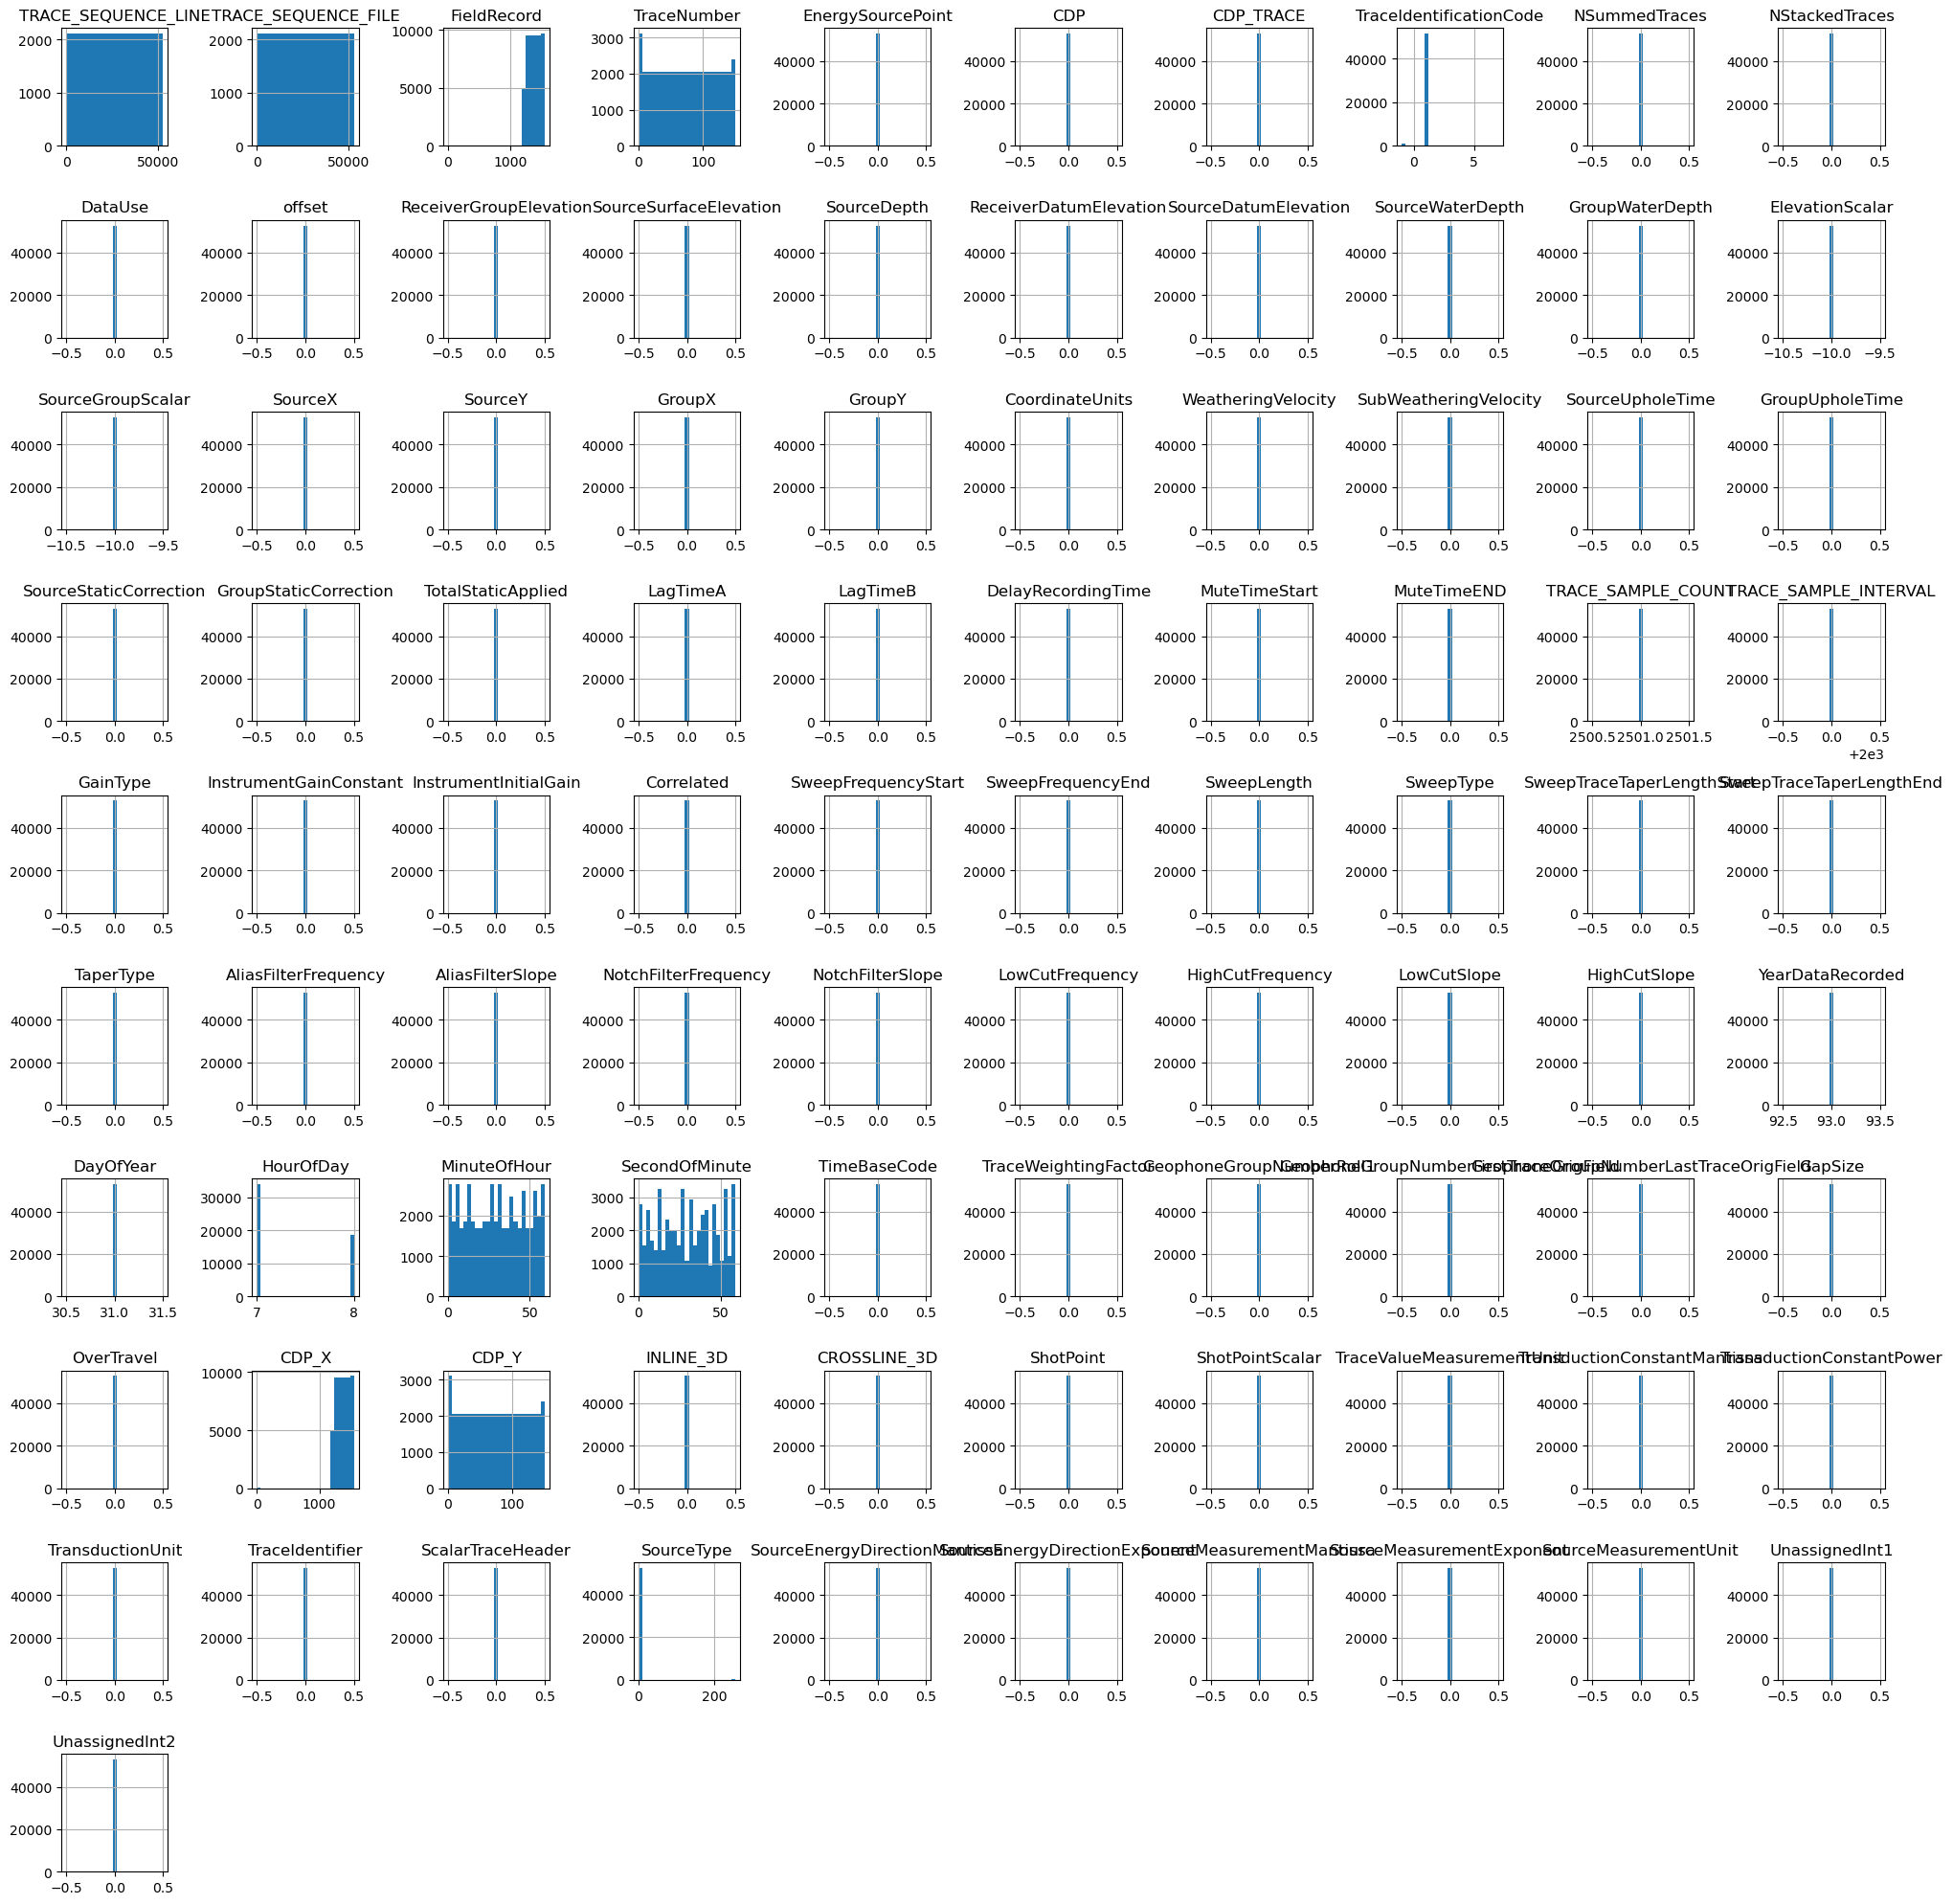

In [11]:
plot = scrape.hist(bins=25, figsize=(20, 20))
plt.tight_layout()
plt.show()

In [13]:
# Parâmetros fornecidos
dxch = 26.67     # Distância entre os canais (canal spacing)
lstr = 4000.0    # Comprimento do streamer
dxsh = 29.67     # Distância entre os tiros
d0 = 241.1       # Offset mínimo
n = 9            # Aqui é n = número do primeiro tiro - 1

# Número do primeiro tiro (fldr). Por exemplo, se o primeiro fldr é 100:
fldr_start = 10
sh0 = fldr_start  # ou: sh0 = n + 1

# Cálculos
nch = lstr / dxch
xcdp0 = ((nch - 1) * dxch) / 2 + (sh0 - 1) * dxsh
cdp0 = (2 * xcdp0) / dxch

# Exibir e salvar os resultados
params = [dxch, dxsh, d0, nch, sh0, xcdp0, cdp0]
print("dxch dxsh d0 nch sh0 xcdp0 cdp0")
print(" ".join([f"{p:.4f}" for p in params]))

# Escreve no arquivo 'params.in'
with open("params.in", "w") as f:
    f.write(" ".join([str(p) for p in params]) + "\n")


dxch dxsh d0 nch sh0 xcdp0 cdp0
26.6700 29.6700 241.1000 149.9813 10.0000 2253.6950 169.0060


In [31]:
stream.


<bound method Dataset.head of <xarray.Dataset> Size: 529MB
Dimensions:  (cdp: 52822, samples: 2501)
Coordinates:
  * cdp      (cdp) int32 211kB 1 2 3 4 5 6 ... 52818 52819 52820 52821 52822
  * samples  (samples) float32 10kB 0.0 2.0 4.0 ... 4.996e+03 4.998e+03 5e+03
Data variables:
    data     (cdp, samples) float32 528MB ...
Attributes:
    seisnc:   {"coord_scalar": -10.0, "coord_scaled": false}>

In [32]:
from obspy.io.segy.core import _read_segy
import numpy as np

# Lê o arquivo SEGY
stream = _read_segy(segy_file, unpack_trace_headers=True)

# Parâmetros de geometria
dxch = 26.67          # Distância entre canais
dxsh = 29.67          # Distância entre tiros
d0 = 241.1            # Offset inicial
lstr = 4000           # Comprimento do streamer
sh0 = 1555            # fldr inicial - 1
nch = int(lstr / dxch)

# Atualiza headers
for trace in stream.traces:
    header = trace.stats.segy.trace_header

    # Usa os nomes corretos do dicionário do cabeçalho
    fldr = header.original_field_record_number
    tracf = header.trace_number_within_the_original_field_record

    # Calcula geometria
    of = dxch * (tracf - 1) + d0
    xcdp = ((nch - tracf) * dxch) / 2 + (fldr - sh0) * dxsh
    cdp = int((2 * xcdp / dxch) + 1)
    sx = d0 + (nch - 1) * dxch + (fldr - sh0) * dxsh
    gx = sx - of

    # Atualiza os headers
    header.source_coordinate_x = int(sx)
    header.group_coordinate_x = int(gx)
    header.cdp = int(cdp)
    header.offset = int(of)

print(int(cdp),int(of))

# Garante que o header textual termina com o padrão SEG-Y
#texthead = stream.textual_file_header.decode('ascii', errors='ignore')
#lines = texthead.splitlines()
#if len(lines) < 40:
    #lines += ['C{:02d} '.format(len(lines) + i + 1) + ' ' * 73 for i in range(40 - len(lines))]
#lines[39] = 'C40 END TEXTUAL HEADER'
#stream.textual_file_header = '\n'.join(lines).encode('ascii')

# Salva em novo arquivo
stream.write("/home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_teste_SEGY/geometria/caravelab_geom2.sgy", format="SEGY", data_encoding=5)


-3309 214


/home/enseadamartel/Programs/anaconda3/lib/python3.13/site-packages/obspy/io/segy/segy.py:362: SEGYInvalidTextualHeaderWarning: The end header mark in the textual header should be set as 'C40 END TEXTUAL HEADER' or as 'C40 END EBCDIC        ' for a fully valid SEG-Y file. It is set to 'C40 END ASCII         ' which will be written to the file. Please change it if you want a fully valid file.
  warnings.warn(msg, SEGYInvalidTextualHeaderWarning)


In [42]:
stream



<xarray.Dataset> Size: 529MB
Dimensions:  (cdp: 52822, samples: 2501)
Coordinates:
  * cdp      (cdp) int32 211kB 1 2 3 4 5 6 ... 52818 52819 52820 52821 52822
  * samples  (samples) float32 10kB 0.0 2.0 4.0 ... 4.996e+03 4.998e+03 5e+03
Data variables:
    data     (cdp, samples) float32 528MB ...
Attributes:
    seisnc:   {"coord_scalar": -10.0, "coord_scaled": false}

In [34]:
from obspy.io.segy.core import _read_segy
import numpy as np

# Lê o arquivo SEGY
stream = xr.open_dataset(segy_file, dim_byte_fields={'cdp': 5})

# Parâmetros de geometria
dxch = 26.67          # Distância entre canais
dxsh = 29.67          # Distância entre tiros
d0 = 241.1            # Offset inicial
lstr = 4000           # Comprimento do streamer
sh0 = 1555            # fldr inicial - 1
nch = int(lstr / dxch)

# Atualiza headers
for trace in stream:
    header = trace.siesnc

seisnc.attrs.update({
    'processing_sequence': 'DENOISE->DMO->PSTM->MIG->QCOMP',
    'filter_parameters': 'Ormsby 5-10-60-70 Hz',
    'bin_size': '25m x 25m',
    'datum': 'WGS84',
    'vertical_units': 'milliseconds'
})
    
    # Usa os nomes corretos do dicionário do cabeçalho
    fldr = header.original_field_record_number
    tracf = header.trace_number_within_the_original_field_record

    # Calcula geometria
    of = dxch * (tracf - 1) + d0
    xcdp = ((nch - tracf) * dxch) / 2 + (fldr - sh0) * dxsh
    cdp = int((2 * xcdp / dxch) + 1)
    sx = d0 + (nch - 1) * dxch + (fldr - sh0) * dxsh
    gx = sx - of

    # Atualiza os headers
    header.source_coordinate_x = int(sx)
    header.group_coordinate_x = int(gx)
    header.cdp = int(cdp)
    header.offset = int(of)

print(int(cdp),int(of))

# Garante que o header textual termina com o padrão SEG-Y
#texthead = stream.textual_file_header.decode('ascii', errors='ignore')
#lines = texthead.splitlines()
#if len(lines) < 40:
    #lines += ['C{:02d} '.format(len(lines) + i + 1) + ' ' * 73 for i in range(40 - len(lines))]
#lines[39] = 'C40 END TEXTUAL HEADER'
#stream.textual_file_header = '\n'.join(lines).encode('ascii')

# Salva em novo arquivo
stream.write("/home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_teste_SEGY/geometria/caravelab_geom2.sgy", format="SEGY", data_encoding=5)


Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/52.8k [00:00<?, ? traces/s]

AttributeError: 'str' object has no attribute 'attrs'

In [15]:
data_geometria = xr.open_dataset("/home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_teste_SEGY/geometria/caravelab_geom2.sgy", dim_byte_fields={'cdp': 5})

Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/52.8k [00:00<?, ? traces/s]

In [25]:
scrape = segy_header_scrape("/home/enseadamartel/Documents/OS2_dIOGO_2025/01_dados_brutos/Dados_teste_SEGY/geometria/caravelab_geom2.sgy", partial_scan=None)

Processing Chunks:   0%|          | 0.00/1.00 [00:00<?, ? trace-chunks/s]

Reading header:   0%|          | 0.00/52.8k [00:00<?, ? traces/s]

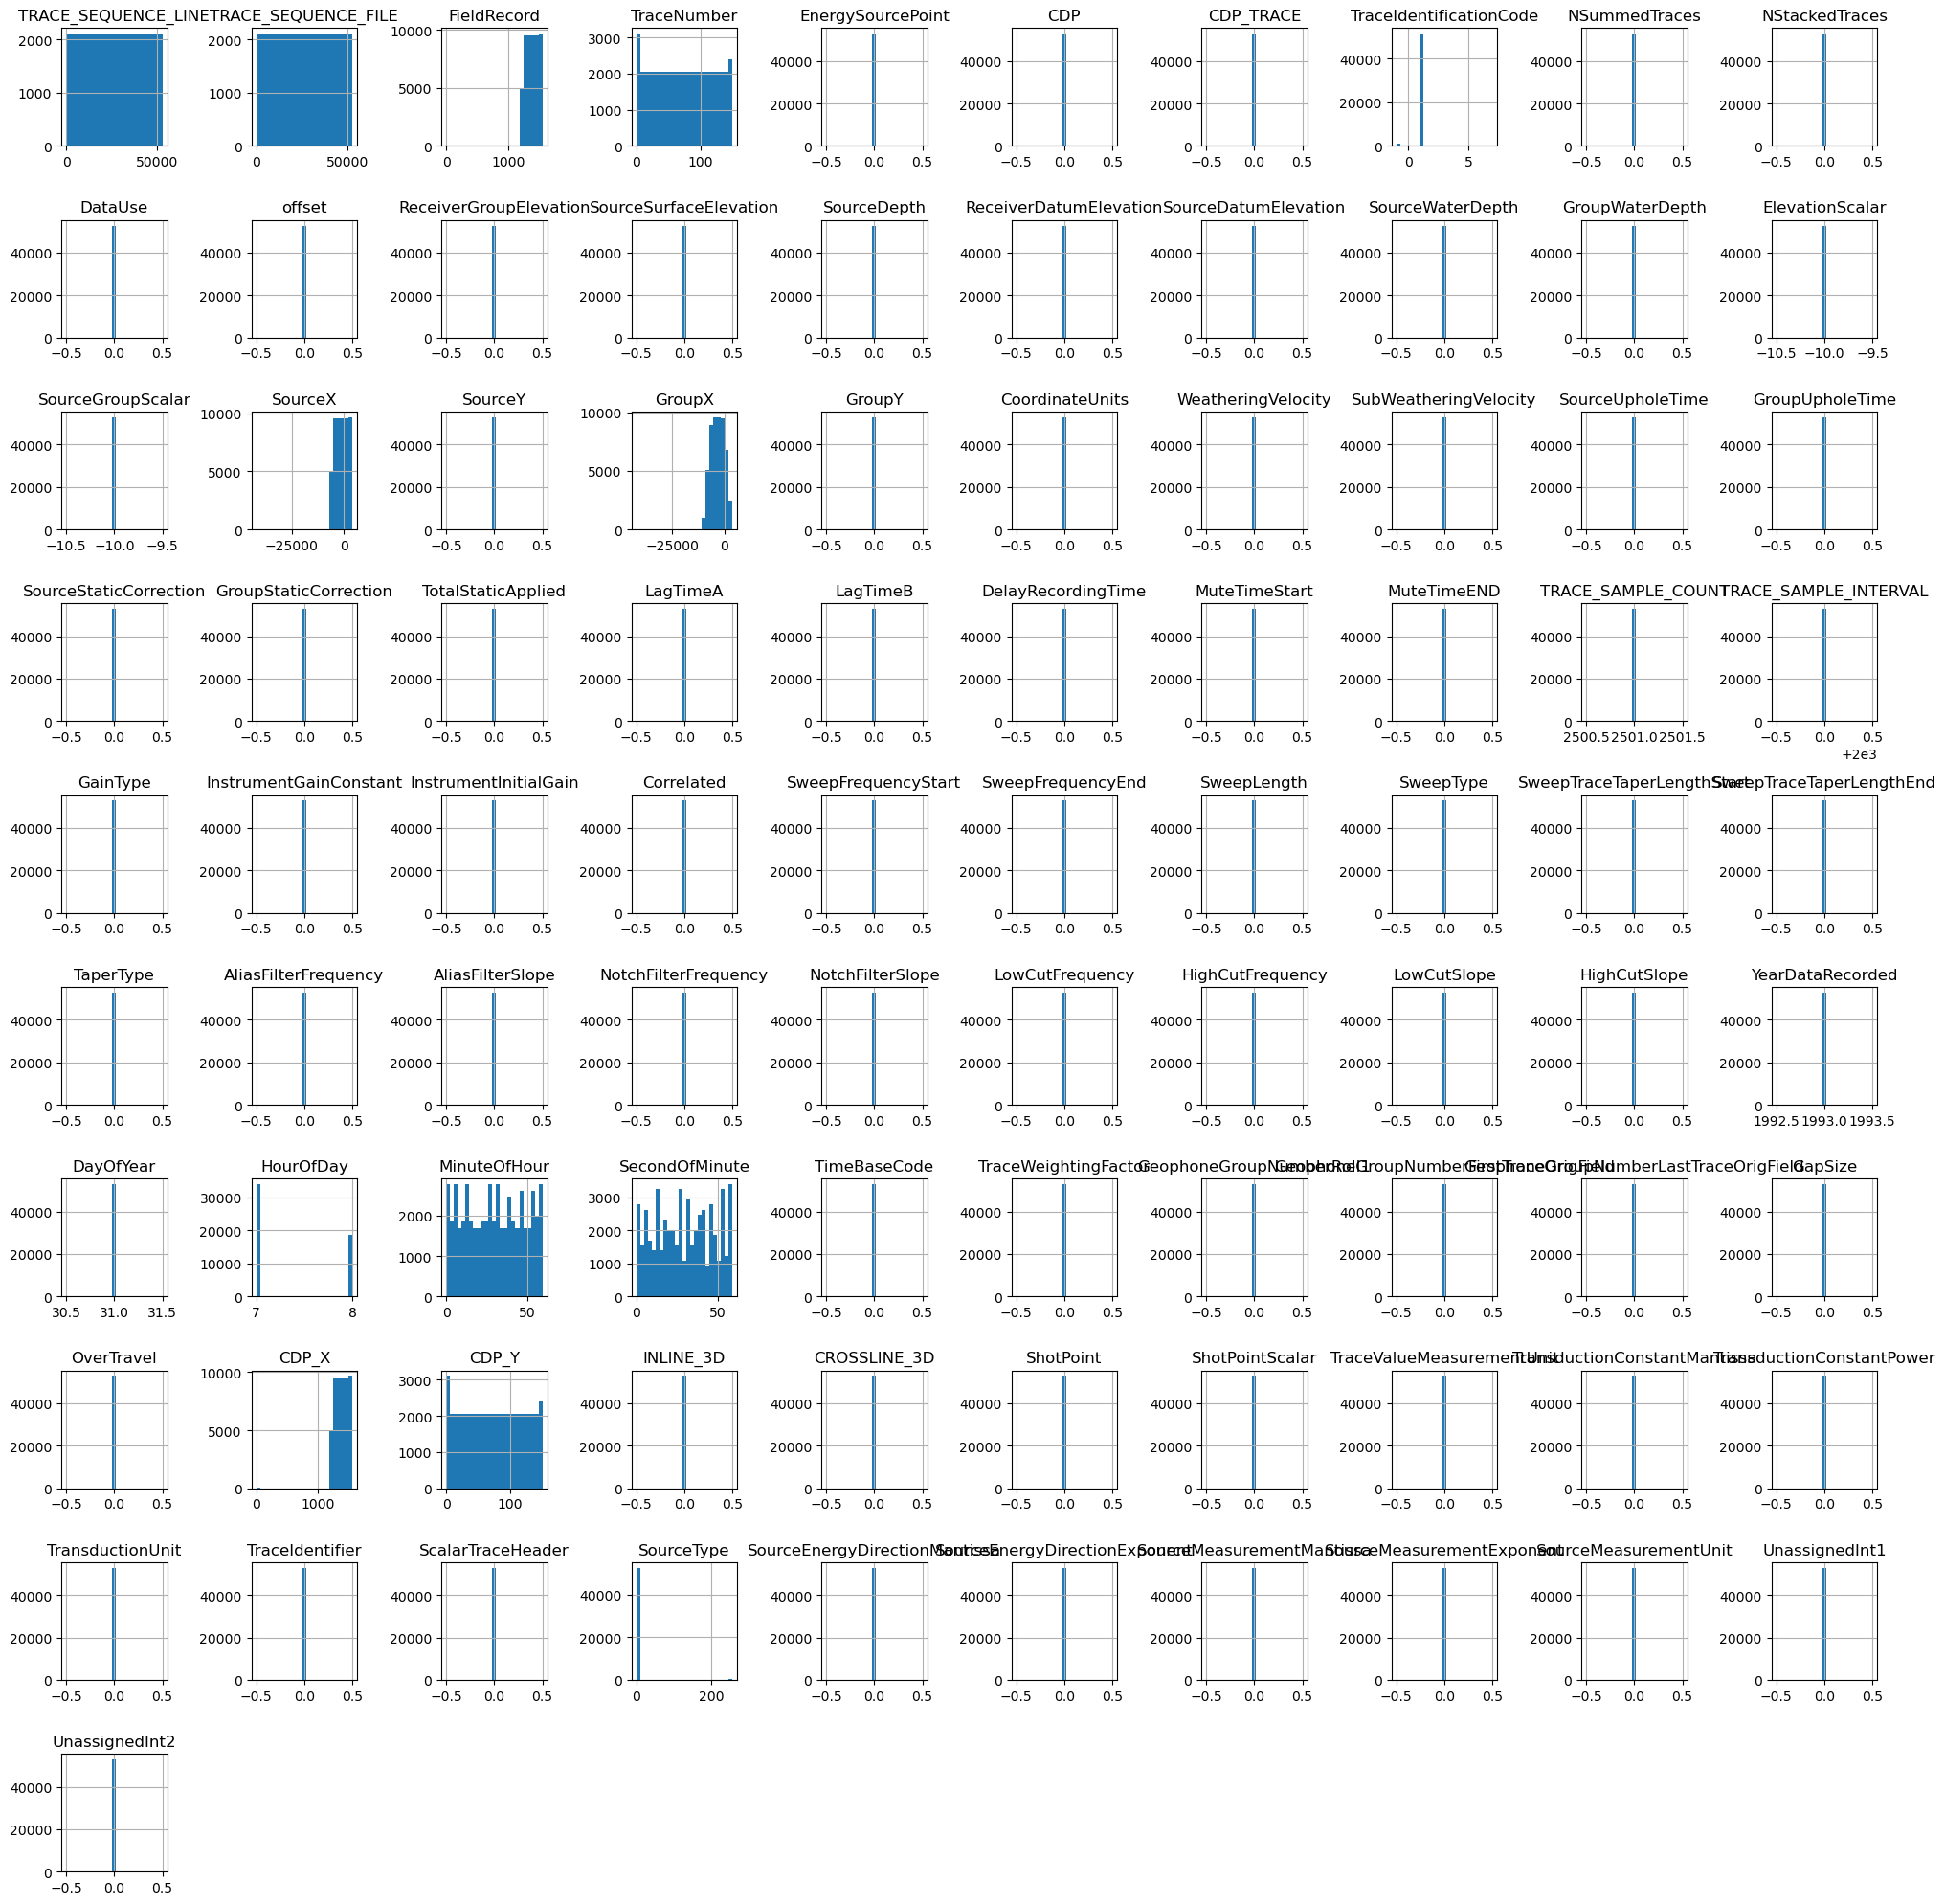

In [26]:
plot = scrape.hist(bins=25, figsize=(20, 20))
plt.tight_layout()
plt.show()

In [44]:
scrape.u

0        1
1        2
2        3
3        4
4        5
        ..
52817    0
52818    0
52819    0
52820    0
52821    0
Name: TraceNumber, Length: 52822, dtype: int16